# Hayward Black Hole

$$ f_\omega(r)=1-\frac{2Mr^2}{r^3+2M\epsilon^2}-\frac{c}{r^{3\omega +1}}$$

con $c$ cte normalización. Eligiendo $\omega=-\frac{2}{3}$, $f_\omega(r)$ tiene 3 horizontes. También encontrando una relación entre la masa del agujero negro $M_\omega$ y sus radio horizontes $f_\omega(r_h)=0$

$$ f_\omega(r)=1-\frac{2Mr^2}{r^3+2M\epsilon^2}-cr \Rightarrow M_{\omega}(r_{h})=\frac{1}{2}\frac{r^3_h(1-cr_h)}{r^2_h+c\epsilon_h - \epsilon^2}$$

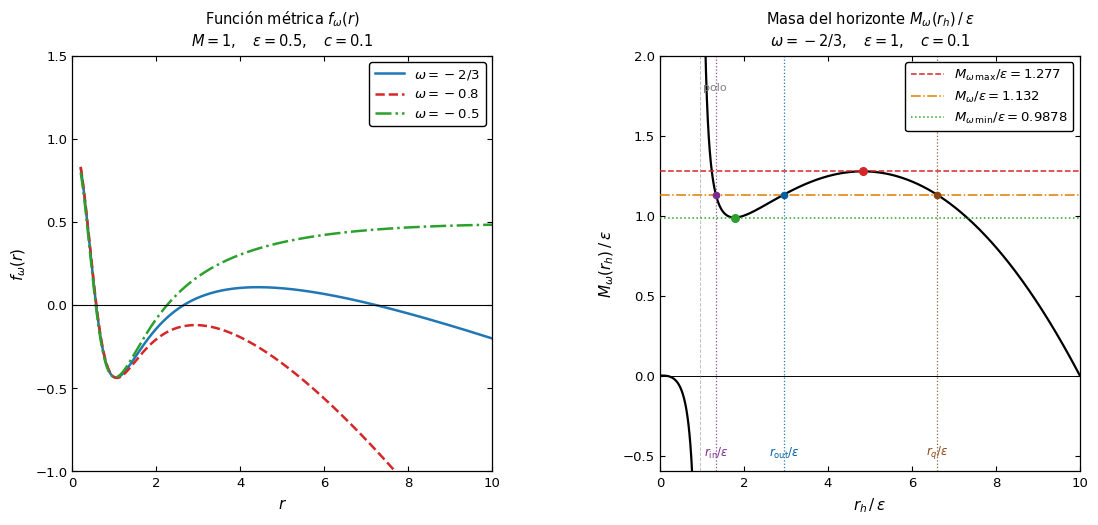

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "white",
    "axes.edgecolor":   "black",
    "axes.linewidth":   0.9,
    "font.family":      "DejaVu Sans",
    "font.size":        11,
    "axes.titlesize":   11,
    "axes.labelsize":   11,
    "legend.fontsize":  9.5,
    "xtick.labelsize":  9.5,
    "ytick.labelsize":  9.5,
    "xtick.direction":  "in",
    "ytick.direction":  "in",
    "xtick.top":        True,
    "ytick.right":      True,
})

# ════════════════════════════════════════════════════════════════════════════
# Funciones
# ════════════════════════════════════════════════════════════════════════════

def f_omega_gen(r, M, eps, c, omega):
    """f = 1 - 2Mr²/(r³+2Mε²) - c/r^{3ω+1}"""
    hayward = 2.0 * M * r**2 / (r**3 + 2.0 * M * eps**2)
    quint   = c / r**(3.0 * omega + 1.0)
    return 1.0 - hayward - quint

def M_omega_func(r, eps, c):
    """M_ω(r_h) = (1/2) r_h³(1−c·r_h) / (r_h²+c·ε²·r_h−ε²)  [ec. 5]"""
    num   = 0.5 * r**3 * (1.0 - c * r)
    denom = r**2 + c * eps**2 * r - eps**2
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(np.abs(denom) > 1e-10, num / denom, np.nan)

# ════════════════════════════════════════════════════════════════════════════
# Parámetros
# Fig. 1: M=1, ε=0.5, c=0.1
# Fig. 2: ε=1,        c=0.1  → Mmax/ε=1.277, Mmin/ε=0.9878
# ════════════════════════════════════════════════════════════════════════════
eps1, M1, c1 = 0.5, 1.0, 0.1
eps2, c2     = 1.0, 0.1

# Polo de M_ω: r_pole = [sqrt(c²ε²+4) − cε]·ε / 2
r_pole2   = (np.sqrt(c2**2 * eps2**2 + 4.0) - c2 * eps2) * eps2 / 2.0
pole_norm = r_pole2 / eps2   # en unidades de ε

# ════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(13, 5.4))
gs  = gridspec.GridSpec(1, 2, figure=fig, wspace=0.40)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])

# ────────────────────────────────────────────────────────────────────────────
# PANEL 1 — f_ω(r) vs r
# ────────────────────────────────────────────────────────────────────────────
r_raw = np.linspace(0.20, 10.0, 10000)

omegas = [-2/3,      -0.8,      -0.5     ]
colors = ["#1f77b4", "#d62728", "#2ca02c"]
lstyle = ["-",       "--",      "-."     ]
labels = [r"$\omega = -2/3$",
          r"$\omega = -0.8$",
          r"$\omega = -0.5$"]

for om, col, ls, lab in zip(omegas, colors, lstyle, labels):
    f = f_omega_gen(r_raw, M1, eps1, c1, om)
    ax1.plot(r_raw, f, color=col, lw=1.8, linestyle=ls, label=lab)

ax1.axhline(0, color="black", lw=0.8, ls="-")

ax1.set_xlim(0, 10)
ax1.set_ylim(-1.0, 1.5)
ax1.set_xlabel(r"$r$", labelpad=5)
ax1.set_ylabel(r"$f_\omega(r)$", labelpad=5)
ax1.set_title(
    r"Función métrica $f_\omega(r)$"                + "\n"
    r"$M = 1,\quad \epsilon = 0.5,\quad c = 0.1$",
    pad=7, fontsize=10.5
)
ax1.legend(loc="upper right", framealpha=1.0,
           edgecolor="black", handlelength=2.2)

# ────────────────────────────────────────────────────────────────────────────
# PANEL 2 — M_ω/ε vs r_h/ε
# ────────────────────────────────────────────────────────────────────────────
r_h_raw  = np.linspace(0.01, 10.5, 500000)
r_h_norm = r_h_raw / eps2
Mw_norm  = M_omega_func(r_h_raw, eps2, c2) / eps2

# Enmascarar el polo
denom_v   = r_h_raw**2 + c2 * eps2**2 * r_h_raw - eps2**2
pole_mask = np.abs(denom_v) < 0.015
Mw_norm[pole_mask] = np.nan

# Separar ramas izquierda y derecha
left_mask  = r_h_norm < pole_norm - 0.01
right_mask = r_h_norm > pole_norm + 0.01

ax2.plot(r_h_norm[left_mask],  Mw_norm[left_mask],  color="black", lw=1.6)
ax2.plot(r_h_norm[right_mask], Mw_norm[right_mask], color="black", lw=1.6)
ax2.axhline(0, color="black", lw=0.7)

# ── Líneas horizontales con colores y entradas en la leyenda ─────────────────
Mmax_norm = 1.277
Mmid_norm = 1.132
Mmin_norm = 0.9878

h_lines = [
    (Mmax_norm, "#d62728", "--",
     r"$M_{\omega\,\max}/\epsilon = 1.277$"),
    (Mmid_norm, "#e07b00", "-.",
     r"$M_\omega/\epsilon = 1.132$"),
    (Mmin_norm, "#2ca02c", ":",
     r"$M_{\omega\,\min}/\epsilon = 0.9878$"),
]

for Mval, col, ls, lab in h_lines:
    ax2.axhline(Mval, color=col, lw=1.1, ls=ls, label=lab, zorder=3)

# ── Puntos sobre la curva en los extremos (rama derecha) ─────────────────────
right_r  = r_h_norm[right_mask]
right_Mw = Mw_norm[right_mask]
region   = (right_r > 1.0) & (right_r < 8.0)
dMw      = np.diff(right_Mw[region])
r_reg    = right_r[region]
M_reg    = right_Mw[region]

for sc in np.where(np.diff(np.sign(dMw)))[0]:
    ri = r_reg[sc + 1]
    Mi = M_reg[sc + 1]
    col_pt = "#d62728" if Mi > 1.2 else "#2ca02c"
    ax2.plot(ri, Mi, "o", color=col_pt, ms=5.5, zorder=7)

# ── Horizontes para M_ω = 1.132 (tres raíces de f_ω = 0) ────────────────────
M_test = Mmid_norm * eps2
r_fine = np.linspace(0.05, 10.5, 400000)
f_fine = f_omega_gen(r_fine, M_test, eps2, c2, -2.0 / 3.0)

horizons = []
for sc in np.where(np.diff(np.sign(f_fine)))[0]:
    ra, rb = r_fine[sc], r_fine[sc + 1]
    for _ in range(80):
        rm = 0.5 * (ra + rb)
        if (f_omega_gen(rm, M_test, eps2, c2, -2/3)
                * f_omega_gen(ra, M_test, eps2, c2, -2/3) < 0):
            rb = rm
        else:
            ra = rm
    horizons.append(0.5 * (ra + rb) / eps2)

h_names   = [r"$r_{\rm in}/\epsilon$",
             r"$r_{\rm out}/\epsilon$",
             r"$r_q/\epsilon$"]
h_vcolors = ["#7b2d8b", "#005fa3", "#8b4513"]

for rh, hn, hc in zip(horizons, h_names, h_vcolors):
    ax2.axvline(rh, color=hc, lw=0.9, ls=":", alpha=0.85)
    ax2.plot(rh, Mmid_norm, "o", color=hc, ms=4.5, zorder=8)
    ax2.text(rh, -0.53, hn, fontsize=8.5,
             ha="center", va="bottom", color=hc)

# ── Línea vertical en el polo ─────────────────────────────────────────────────
ax2.axvline(pole_norm, color="gray", lw=0.7, ls="--", alpha=0.5)
ax2.text(pole_norm + 0.08, 1.80, "polo", fontsize=8,
         color="gray", ha="left", va="center")

ax2.set_xlim(0, 10)
ax2.set_ylim(-0.6, 2.0)
ax2.set_xlabel(r"$r_h\,/\,\epsilon$", labelpad=5)
ax2.set_ylabel(r"$M_\omega(r_h)\,/\,\epsilon$", labelpad=5)
ax2.set_title(
    r"Masa del horizonte $M_\omega(r_h)\,/\,\epsilon$"  + "\n"
    r"$\omega = -2/3,\quad \epsilon = 1,\quad c = 0.1$",
    pad=7, fontsize=10.5
)
ax2.legend(loc="upper right", framealpha=1.0,
           edgecolor="black", handlelength=2.5)

# ════════════════════════════════════════════════════════════════════════════
plt.tight_layout()
plt.savefig("hayward_color.png", dpi=160,
            bbox_inches="tight", facecolor="white")

# Horizontes 

$$r^3_h - \frac{1-3c^2 \epsilon^2}{2c}r^2_h - 3\epsilon^2 r_h + \frac{3\epsilon^2}{2c}= 0$$

Cuando 3 horizontes colapsan en uno sólo se tiene el valor crítico para $c$ $r_{in}=r_{out}=r_{r_q}$

$$c_{crit}\epsilon = \frac{1}{6}\sqrt{30\sqrt{5}-66} \approx 0.173368$$

- $c > c_{\text{crit}}$: No hay BH para ningún valor de $M_\omega$

- $c < c_{\text{crit}}$: El BH puede tener 2 o 3 horizontes sólo para valores de masa $M_{\omega \min} < M_\omega < M_{\omega \max}$

$$p=-\frac{1+30c^2\epsilon^2 + 9c^4 \epsilon^4}{12c^2} \quad \quad q= \frac{-1 +27c^6 \epsilon^6 +135 c^4 \epsilon^4 + 117c^2 \epsilon^2}{108c^3}$$

$$\chi (\epsilon, c) = \frac{\sqrt{1+30c^2\epsilon^2 + 9 c^4 \epsilon^4}}{3c} \quad \quad \cos(3\theta) = \Xi(\epsilon, c)= \frac{1 -27c^6 \epsilon^6 -135 c^4 \epsilon^4 - 117c^2 \epsilon^2}{(1+30c^2\epsilon^2 + 9c^4 \epsilon^4)^{3/2}} $$

Por lo tanto, los horizontes estarán dados por:

$$r_{h,k}=u_k + h = \frac{1-3c^2 \epsilon^2}{6c} + \chi(\epsilon, c)\cos(\frac{1}{3}\arccos (\Xi (\epsilon, c)) + \frac{2\pi k}{3}) $$

In [3]:
import numpy as np

print("=" * 70)
print("Comparación numérica: forma trigonométrica vs ecuaciones del paper")
print("=" * 70)

# ── Parámetros ────────────────────────────────────────────────────────────
c   = 0.1
eps = 1.0
x   = c * eps

# ── Coeficientes de la cúbica deprimida ───────────────────────────────────
alpha = (1 - 3*x**2) / (6*c)
p     = -(1 + 30*x**2 + 9*x**4) / (12*c**2)
q     = (-1 + 117*x**2 + 135*x**4 + 27*x**6) / (108*c**3)

print(f"\nParámetros: c = {c},  ε = {eps},  cε = {x}")
print(f"\nCoeficientes de t³ + pt + q = 0:")
print(f"  α = (1 − 3x²)/(6c)                          = {alpha:.10f}")
print(f"  p = −(1 + 30x² + 9x⁴)/(12c²)               = {p:.10f}")
print(f"  q = (−1 + 117x² + 135x⁴ + 27x⁶)/(108c³)   = {q:.10f}")
print(f"  D = q²/4 + p³/27 = {q**2/4 + p**3/27:.6e}  (< 0 → casus irreducibilis ✓)")

# ════════════════════════════════════════════════════════════════════════════
# MÉTODO TRIGONOMÉTRICO DE VIÈTE
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "─" * 70)
print("MÉTODO TRIGONOMÉTRICO DE VIÈTE")
print("─" * 70)

m = np.sqrt(1 + 30*x**2 + 9*x**4) / (3*c)

cos3phi = (1 - 117*x**2 - 135*x**4 - 27*x**6) \
          / (1 + 30*x**2 + 9*x**4)**1.5

phi0 = np.arccos(np.clip(cos3phi, -1.0, 1.0))

print(f"\n  m        = √(1+30x²+9x⁴) / (3c)  = {m:.10f}")
print(f"  cos(3φ₀) = (1−117x²−135x⁴−27x⁶) / (1+30x²+9x⁴)^(3/2)")
print(f"           = {cos3phi:.10f}")
print(f"  φ₀       = arccos(cos3φ₀)          = {phi0:.10f} rad")
print(f"           =                            {np.degrees(phi0):.6f}°")

print(f"\n  Raíces  r_{{h,k}} = α + m·cos((φ₀ + 2πk)/3):")
roots_viet = []
nombres_v  = ["k=0  r_out = r_q  (Nariai, M_max)",
              "k=1  r_polo       (no física)    ",
              "k=2  r_in = r_out (frío,   M_min)"]
for k in range(3):
    phi_k = (phi0 + 2*np.pi*k) / 3
    tk    = m * np.cos(phi_k)
    rk    = alpha + tk
    roots_viet.append(rk)
    print(f"    {nombres_v[k]}:  r_h = {rk:.10f}")

# ════════════════════════════════════════════════════════════════════════════
# ECUACIONES DEL PAPER  (ecs. 7 y 9)
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "─" * 70)
print("ECUACIONES DEL PAPER (ecs. 7 y 9)")
print("─" * 70)

# Δ del paper (ec. 8):
# Δ = (1 − 117x² − 135x⁴ − 27x⁶ + 18√(33x⁴ + 9x⁶ − x²))^(1/3)
inner_sqrt = 33*x**4 + 9*x**6 - x**2
print(f"\n  Argumento de √ en Δ:  33x⁴+9x⁶−x² = {inner_sqrt:.10f}"
      f"  ({'≥0' if inner_sqrt >= 0 else '< 0 → complejo'})")

arg_Delta = (1 - 117*x**2 - 135*x**4 - 27*x**6
             + 18*np.sqrt(inner_sqrt + 0j))
Delta     = arg_Delta**(1/3)
print(f"  Δ³ = {arg_Delta}")
print(f"  Δ  = {Delta}   (complejo: casus irreducibilis)")

A_num = 1 + 30*x**2 + 9*x**4   # numerador recurrente

# Ec. (7): r_out = r_q   [caso Nariai, M_max]
r7 = ( -(3*x**2 - 1)/(6*c)
       + A_num / (6*c*Delta)
       + Delta  / (6*c) )

# Ec. (9): r_in = r_out  [caso frío,   M_min]
#          r_polo        [polo, no física]
br_re = A_num/Delta + Delta
br_im = A_num/Delta - Delta

r9a = ( -(3*x**2-1)/(6*c)
        - br_re / (12*c)
        + 1j*np.sqrt(3)*br_im / (12*c) )

r9b = ( -(3*x**2-1)/(6*c)
        - br_re / (12*c)
        - 1j*np.sqrt(3)*br_im / (12*c) )

roots_paper  = [r7.real, r9a.real, r9b.real]
nombres_p    = ["Ec.(7)  r_out=r_q  (Nariai, M_max)",
                "Ec.(9a) r_in=r_out (frío,   M_min)",
                "Ec.(9b) r_polo     (no física)    "]

print(f"\n  Raíces del paper:")
for nom, rv in zip(nombres_p, roots_paper):
    print(f"    {nom}:  r_h = {rv:.10f}")

# ════════════════════════════════════════════════════════════════════════════
# TABLA COMPARATIVA
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("TABLA COMPARATIVA")
print("=" * 70)

# Ordenar ambos conjuntos de mayor a menor para comparar par a par
rv_sorted = sorted(roots_viet,  reverse=True)
rp_sorted = sorted(roots_paper, reverse=True)
labels    = ["r_out = r_q  (Nariai, M_max)",
             "r_in = r_out (frío,   M_min)",
             "r_polo       (no física)    "]

print(f"\n  {'Horizonte':<32} {'Viète':>13} {'Paper':>13} {'|Δr|':>12}")
print("  " + "─" * 72)
for lab, rv, rp in zip(labels, rv_sorted, rp_sorted):
    print(f"  {lab:<32} {rv:>13.8f} {rp:>13.8f} {abs(rv-rp):>12.2e}")

# ════════════════════════════════════════════════════════════════════════════
# VERIFICACIÓN: sustituir en la cúbica original P(r) = 0
# ════════════════════════════════════════════════════════════════════════════
print("\n" + "=" * 70)
print("VERIFICACIÓN: |P(r)| con P(r) = r³ − (1−3x²)/(2c)·r² − 3ε²·r + 3ε²/(2c)")
print("=" * 70)

def P(r):
    return (r**3
            - (1 - 3*x**2)/(2*c) * r**2
            - 3*eps**2 * r
            + 3*eps**2/(2*c))

print(f"\n  {'Método':<10} {'Horizonte':<32} {'r_h':>12} {'|P(r_h)|':>12}")
print("  " + "─" * 70)

for label, rvals, noms in [
        ("Viète",  rv_sorted, labels),
        ("Paper",  rp_sorted, labels)]:
    for rv, nom in zip(rvals, noms):
        print(f"  {label:<10} {nom:<32} {rv:>12.8f} {abs(P(rv)):>12.2e}")
    print()

# ════════════════════════════════════════════════════════════════════════════
# RESUMEN FINAL
# ════════════════════════════════════════════════════════════════════════════
print("=" * 70)
print("RESUMEN")
print("=" * 70)
print(f"""
  Diferencias |Viète − Paper| para cada horizonte:

    r_out = r_q  (Nariai):  {abs(rv_sorted[0]-rp_sorted[0]):.2e}
    r_in  = r_out (frío):   {abs(rv_sorted[1]-rp_sorted[1]):.2e}
    r_polo (no física):     {abs(rv_sorted[2]-rp_sorted[2]):.2e}

  Todas las diferencias son del orden del error de máquina (∼10⁻¹⁵),
  confirmando que la forma trigonométrica de Viète y las ecuaciones
  (7) y (9) del paper son algebraicamente equivalentes.  ✓
""")

Comparación numérica: forma trigonométrica vs ecuaciones del paper

Parámetros: c = 0.1,  ε = 1.0,  cε = 0.1

Coeficientes de t³ + pt + q = 0:
  α = (1 − 3x²)/(6c)                          = 1.6166666667
  p = −(1 + 30x² + 9x⁴)/(12c²)               = -10.8408333333
  q = (−1 + 117x² + 135x⁴ + 27x⁶)/(108c³)   = 1.6993240741
  D = q²/4 + p³/27 = -4.646528e+01  (< 0 → casus irreducibilis ✓)

──────────────────────────────────────────────────────────────────────
MÉTODO TRIGONOMÉTRICO DE VIÈTE
──────────────────────────────────────────────────────────────────────

  m        = √(1+30x²+9x⁴) / (3c)  = 3.8019001097
  cos(3φ₀) = (1−117x²−135x⁴−27x⁶) / (1+30x²+9x⁴)^(3/2)
           = -0.1236898592
  φ₀       = arccos(cos3φ₀)          = 1.6948037696 rad
           =                            97.105103°

  Raíces  r_{h,k} = α + m·cos((φ₀ + 2πk)/3):
    k=0  r_out = r_q  (Nariai, M_max):  r_h = 4.8278413012
    k=1  r_polo       (no física)    :  r_h = -1.7516178547
    k=2  r_in = r_out (frío,  

# Geodésicas nulas

## 1- $E^2 - V_{eff}=0$ cuando $\dot{r}=0$ Circular Null Geodesics $V'_{eff}(r_c)=V_{eff}(r_c)=0$

Órbita circular estable: $V''_{eff}(r_c)>0$

Órbita circulas inestable: $V''_{eff}(r_c)<0$

Condición para obtener geodésicas estables e inestables:

$$\frac{E}{L}=\pm \left[ \frac{1}{2r_c} \left( -c + \frac{2M_\omega r_c (r^3_c -4M_\omega \epsilon^2 )}{(r^3_c + 2M_\omega \epsilon^2)^2} \right)\right]^{1/2} $$

## 2- $E^2_1 - V_{eff}>0 $ Se denota como $E=E_1$ que corresponde al caso de geodésica nula abierta

## 3- $E^2_2 - V_{eff}<0$ Se denota como $E=E_2$ que corresponde al caso de geodésica nula cerrada


$$\frac{dr}{d\phi} = \frac{r^2}{L}\sqrt{E^2 - V_{eff}}; \quad \quad V_{eff}=f_{\omega}(r)\frac{L^2}{r^2}$$

$$\left(\frac{du}{d\phi} \right)^2 = \frac{E^2}{L^2} - u^2 + \frac{2M_\omega u^3}{1+2M_\omega \epsilon^2 u^3}+cu $$


rC = 4.338501,  EC = 1.00062913
r_in = 1.2754,  r_out = 3.4887,  r_q = 6.1176

EC: phi_max = 4.6π,  r_final = 4.3386  (rC = 4.3385),  cruza r_out: False
E1: phi_max = 2.74π,  r_final = 1.2767
E2: phi_max = 2.52π,  r_turn = 5.4113

Guardado.


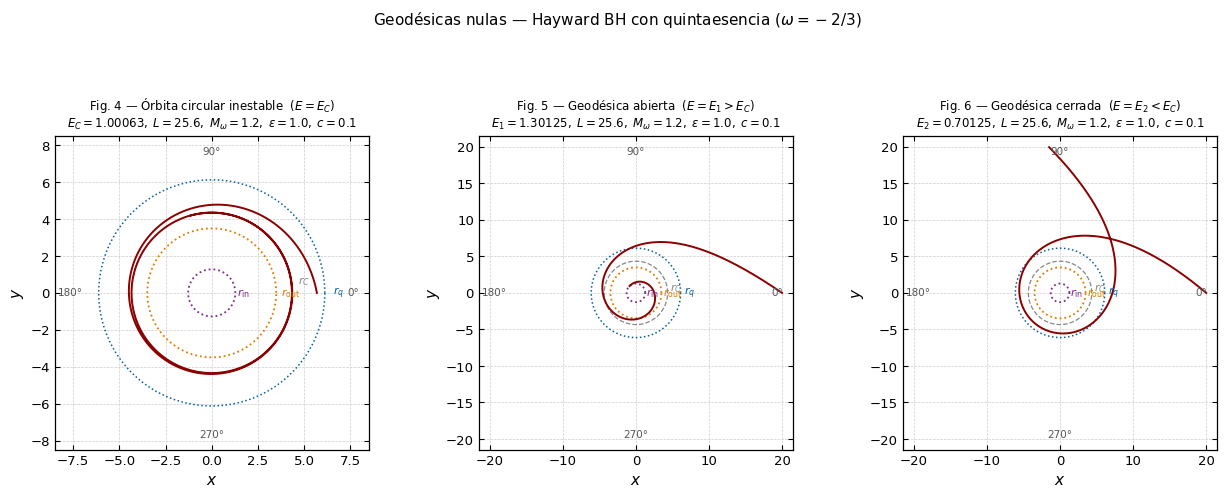

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor":   "black", "axes.linewidth": 0.9,
    "font.family":      "DejaVu Sans", "font.size": 10,
    "xtick.direction":  "in", "ytick.direction": "in",
    "xtick.top": True,  "ytick.right": True,
    "grid.color":       "#cccccc", "grid.linewidth": 0.5,
    "grid.linestyle":   "--",
})

# ════════════════════════════════════════════════════════════════════════════
# Parámetros
# ════════════════════════════════════════════════════════════════════════════
Mw  = 1.2
eps = 1.0
c   = 0.1
L   = 25.6
E1  = 1.30125   # geodésica abierta  (cae al BH)
E2  = 0.70125   # geodésica cerrada  (refleja)

# ════════════════════════════════════════════════════════════════════════════
# Funciones métricas
# ════════════════════════════════════════════════════════════════════════════
def f_omega(r):
    return 1.0 - 2.0*Mw*r**2 / (r**3 + 2.0*Mw*eps**2) - c*r

def g(u, E):
    """g(u) = (E/L)² - u² + 2Mω u³/(1+2Mω ε² u³) + cu  [ec. 21]"""
    return (E/L)**2 - u**2 + 2.0*Mw*u**3 / (1.0 + 2.0*Mw*eps**2*u**3) + c*u

def Veff(r):
    return f_omega(r) * L**2 / r**2

def dVeff(r):
    h = 1e-7
    return (Veff(r + h) - Veff(r - h)) / (2*h)

# ════════════════════════════════════════════════════════════════════════════
# rC y EC exactos
# rC: máximo de Veff  =>  dVeff(rC) = 0
# EC: energía crítica  =>  EC = sqrt(Veff(rC))
# ════════════════════════════════════════════════════════════════════════════
r_scan  = np.linspace(3.0, 7.0, 500000)
dV_scan = np.array([dVeff(r) for r in r_scan])
sc_rc   = np.where(np.diff(np.sign(dV_scan)))[0]
rC = brentq(dVeff, r_scan[sc_rc[0]], r_scan[sc_rc[0]+1])
uC = 1.0 / rC
EC = np.sqrt(Veff(rC))   # raíz doble exacta de g(u, EC) en uC

# ════════════════════════════════════════════════════════════════════════════
# Horizontes: raíces de f_omega(r) = 0
# ════════════════════════════════════════════════════════════════════════════
r_arr = np.linspace(0.05, 15.0, 500000)
f_arr = np.array([f_omega(r) for r in r_arr])
sc_h  = np.where(np.diff(np.sign(f_arr)))[0]
horizons = [brentq(f_omega, r_arr[s], r_arr[s+1]) for s in sc_h]
r_in, r_out, r_q = horizons
u_in_h = 1.0 / r_in

print(f"rC = {rC:.6f},  EC = {EC:.8f}")
print(f"r_in = {r_in:.4f},  r_out = {r_out:.4f},  r_q = {r_q:.4f}")

# ════════════════════════════════════════════════════════════════════════════
# Integración de geodésicas
# ════════════════════════════════════════════════════════════════════════════

def integrate_EC(u0, phi_max, n=3000000):
    """
    Caso EC: fotón espira asintóticamente hacia rC.
    g tiene raíz DOBLE en uC  =>  sqrt(g) -> 0 allí  =>  phi -> inf.
    Se detiene cuando u alcanza uC*0.99998 (a ~0.002% de uC).
    El fotón NO cruza r_out.
    """
    def ode(phi, y):
        return [np.sqrt(max(g(y[0], EC), 0.0))]

    def stop_at_uC(phi, y):
        return y[0] - uC * 0.99998
    stop_at_uC.terminal  = True
    stop_at_uC.direction = 1

    sol = solve_ivp(ode, [0, phi_max], [u0],
                    events=[stop_at_uC],
                    max_step=phi_max / n,
                    rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0]


def integrate_generic(E, u0, phi_max, n=600000):
    """
    Casos E1 (cae al BH) y E2 (refleja).
    Dos eventos de parada:
      1. Horizonte interior r_in  (para E1)
      2. g -> 0 desde arriba      (punto de retorno para E2)
    """
    def ode(phi, y):
        return [np.sqrt(max(g(y[0], E), 0.0))]

    def stop_horizon(phi, y):   # fotón llega a r_in
        return y[0] - u_in_h * 0.999
    stop_horizon.terminal  = True
    stop_horizon.direction = 1

    def stop_gzero(phi, y):     # punto de retorno (g = 0 decreciente)
        return g(y[0], E)
    stop_gzero.terminal  = True
    stop_gzero.direction = -1

    sol = solve_ivp(ode, [0, phi_max], [u0],
                    events=[stop_horizon, stop_gzero],
                    max_step=phi_max / n,
                    rtol=1e-9, atol=1e-11)
    return sol.t, sol.y[0]


# ── Caso EC ───────────────────────────────────────────────────────────────────
uD_ec        = 1.0 / (r_q * 0.93)      # rD entre rC y r_q
phi_ec, u_ec = integrate_EC(uD_ec, 300*np.pi)
r_ec         = 1.0 / u_ec
print(f"\nEC: phi_max = {phi_ec[-1]/np.pi:.1f}π,  "
      f"r_final = {r_ec[-1]:.4f}  (rC = {rC:.4f}),  "
      f"cruza r_out: {r_ec.min() < r_out}")

# ── Caso E1 ───────────────────────────────────────────────────────────────────
uD_e1        = 1.0 / 20.0
phi_e1, u_e1 = integrate_generic(E1, uD_e1, 30*np.pi)
r_e1         = 1.0 / u_e1
print(f"E1: phi_max = {phi_e1[-1]/np.pi:.2f}π,  r_final = {r_e1[-1]:.4f}")

# ── Caso E2 ───────────────────────────────────────────────────────────────────
uD_e2           = 1.0 / 20.0
phi_in, u_in_e2 = integrate_generic(E2, uD_e2, 30*np.pi)
r_in_e2         = 1.0 / u_in_e2
# Reflexión especular en el punto de retorno
phi_out  = 2.0*phi_in[-1] - phi_in[::-1]
r_out_e2 = r_in_e2[::-1]
phi_e2   = np.concatenate([phi_in,    phi_out[1:]])
r_e2     = np.concatenate([r_in_e2, r_out_e2[1:]])
print(f"E2: phi_max = {phi_e2[-1]/np.pi:.2f}π,  "
      f"r_turn = {r_in_e2.min():.4f}")

# ════════════════════════════════════════════════════════════════════════════
# Auxiliares de dibujo
# ════════════════════════════════════════════════════════════════════════════
theta_c = np.linspace(0, 2*np.pi, 800)
cos_c   = np.cos(theta_c)
sin_c   = np.sin(theta_c)

def draw_circle(ax, r, color, lw, ls, zorder=5):
    ax.plot(r*cos_c, r*sin_c,
            color=color, lw=lw, ls=ls, zorder=zorder)

# ════════════════════════════════════════════════════════════════════════════
# Figura
# ════════════════════════════════════════════════════════════════════════════
fig  = plt.figure(figsize=(15, 5.4))
gs   = gridspec.GridSpec(1, 3, figure=fig, wspace=0.35)
axes = [fig.add_subplot(gs[i]) for i in range(3)]

traj_data = [
    (phi_ec, r_ec,
     rf"Fig. 4 — Órbita circular inestable  ($E = E_C$)" + "\n"
     rf"$E_C = {EC:.5f},\; L={L},\; M_\omega={Mw},\; \epsilon={eps},\; c={c}$",
     8.5),
    (phi_e1, r_e1,
     rf"Fig. 5 — Geodésica abierta  ($E = E_1 > E_C$)" + "\n"
     rf"$E_1={E1},\; L={L},\; M_\omega={Mw},\; \epsilon={eps},\; c={c}$",
     21.5),
    (phi_e2, r_e2,
     rf"Fig. 6 — Geodésica cerrada  ($E = E_2 < E_C$)" + "\n"
     rf"$E_2={E2},\; L={L},\; M_\omega={Mw},\; \epsilon={eps},\; c={c}$",
     21.5),
]

for ax, (phi_t, r_t, title, lim) in zip(axes, traj_data):
    ax.set_aspect("equal")
    ax.set_xlim(-lim, lim)
    ax.set_ylim(-lim, lim)

    # Grilla detrás de todo
    ax.grid(True, zorder=0)

    # Horizontes y fotosfera — todos punteados, sin relleno
    draw_circle(ax, r_q,   "#005fa3", lw=1.1, ls=":")
    draw_circle(ax, r_out, "#e07b00", lw=1.3, ls=":")
    draw_circle(ax, r_in,  "#7b2d8b", lw=1.3, ls=":")
    draw_circle(ax, rC,    "#888888", lw=0.9, ls="--")

    # Trayectoria geodésica
    ax.plot(r_t*np.cos(phi_t), r_t*np.sin(phi_t),
            color="darkred", lw=1.4, zorder=7)

    # Etiquetas de horizontes
    off = 1.07
    ax.text(r_in*off,  0.0,     r"$r_{\rm in}$",  fontsize=8,
            color="#7b2d8b", ha="left", va="center", zorder=8)
    ax.text(r_out*off, 0.0,     r"$r_{\rm out}$", fontsize=8,
            color="#e07b00", ha="left", va="center", zorder=8)
    ax.text(r_q*off,   0.0,     r"$r_q$",         fontsize=8,
            color="#005fa3", ha="left", va="center", zorder=8)
    ax.text(rC*off,    rC*0.15, r"$r_C$",         fontsize=8,
            color="#888888", ha="left", va="center", zorder=8)

    # Marcas angulares
    for ang, lbl in [(0,"0°"),(90,"90°"),(180,"180°"),(270,"270°")]:
        rad = np.radians(ang)
        ax.text(lim*0.90*np.cos(rad), lim*0.90*np.sin(rad), lbl,
                ha="center", va="center",
                fontsize=7.5, color="#555555", zorder=8)

    ax.set_xlabel(r"$x$", labelpad=3)
    ax.set_ylabel(r"$y$", labelpad=3)
    ax.set_title(title, fontsize=8.5, pad=6)

fig.suptitle(
    r"Geodésicas nulas — Hayward BH con quintaesencia ($\omega = -2/3$)",
    fontsize=11, y=1.02
)
plt.savefig("geodesics_corrected.png",
            dpi=160, bbox_inches="tight", facecolor="white")
print("\nGuardado.")

# Solución analítica para el caso de orbita circulas inestable E=E_c



rC    = 4.338501
EC    = 1.00062913
alpha = 0.65727256
r_in=1.2754,  r_out=3.4887,  r_q=6.1176

Numérico:  phi_max=4.58π, r_final=4.338588
Analítico: phi_max=4.17π, r_final=4.338689
Guardado.


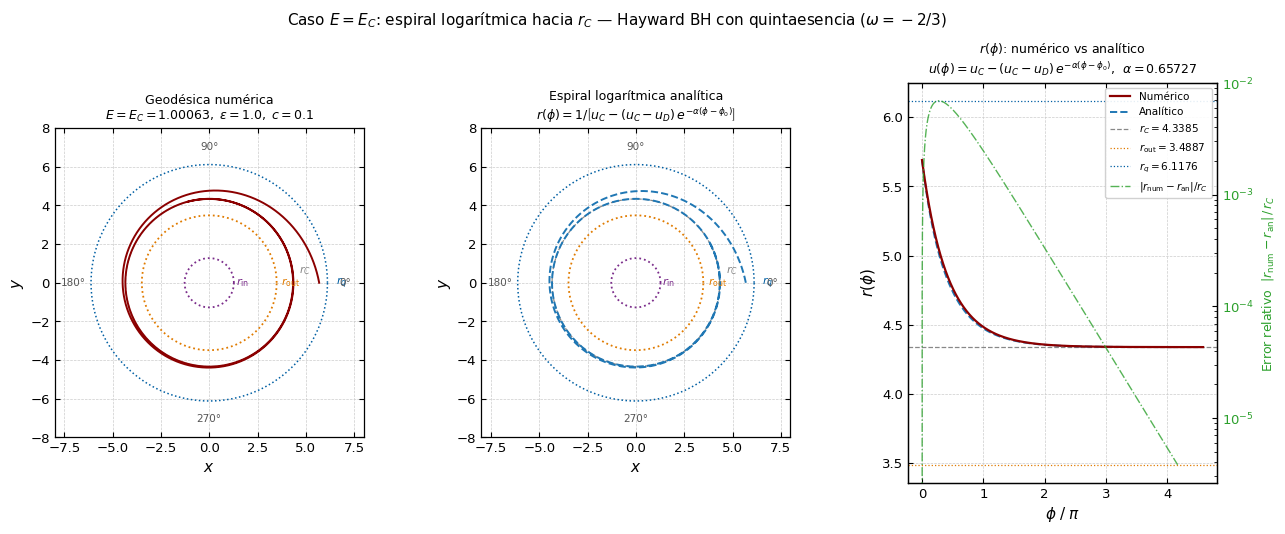

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp
from scipy.optimize import brentq

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor":   "black", "axes.linewidth": 0.9,
    "font.family":      "DejaVu Sans", "font.size": 10,
    "xtick.direction":  "in", "ytick.direction": "in",
    "xtick.top": True,  "ytick.right": True,
    "grid.color":       "#cccccc", "grid.linewidth": 0.5,
    "grid.linestyle":   "--",
})

# ════════════════════════════════════════════════════════════════════════════
# Parámetros
# ════════════════════════════════════════════════════════════════════════════
Mw  = 1.2
eps = 1.0
c   = 0.1
L   = 25.6

# ════════════════════════════════════════════════════════════════════════════
# Funciones
# ════════════════════════════════════════════════════════════════════════════
def f_omega(r):
    return 1.0 - 2.0*Mw*r**2/(r**3 + 2.0*Mw*eps**2) - c*r

def g(u, E):
    """g(u) = (E/L)² - u² + 2Mω u³/(1+2Mω ε² u³) + cu  [ec. 21]"""
    return (E/L)**2 - u**2 + 2.0*Mw*u**3/(1.0 + 2.0*Mw*eps**2*u**3) + c*u

def Veff(r):
    return f_omega(r)*L**2/r**2

def dVeff(r):
    h = 1e-7
    return (Veff(r+h) - Veff(r-h))/(2*h)

def g2prime(uC):
    """Segunda derivada de g en uC: g''(uC) = -2 + [12Mω uC DC - 72Mω² ε² uC⁴]/DC³"""
    DC = 1.0 + 2.0*Mw*eps**2*uC**3
    return -2.0 + (12.0*Mw*uC*DC - 72.0*Mw**2*eps**2*uC**4)/DC**3

# ════════════════════════════════════════════════════════════════════════════
# rC, EC y alpha exactos
#   rC : máximo de Veff  =>  dVeff(rC) = 0
#   EC : energía crítica =>  EC = sqrt(Veff(rC))
#   alpha: tasa espiral  =>  alpha = sqrt(g''(uC)/2)
# ════════════════════════════════════════════════════════════════════════════
r_scan  = np.linspace(3.0, 7.0, 500000)
dV_scan = np.array([dVeff(r) for r in r_scan])
sc_rc   = np.where(np.diff(np.sign(dV_scan)))[0]
rC    = brentq(dVeff, r_scan[sc_rc[0]], r_scan[sc_rc[0]+1])
uC    = 1.0/rC
EC    = np.sqrt(Veff(rC))
alpha = np.sqrt(g2prime(uC)/2.0)

# ════════════════════════════════════════════════════════════════════════════
# Horizontes: raíces de f_omega(r) = 0
# ════════════════════════════════════════════════════════════════════════════
r_arr = np.linspace(0.05, 15.0, 500000)
f_arr = np.array([f_omega(r) for r in r_arr])
sc_h  = np.where(np.diff(np.sign(f_arr)))[0]
horizons = [brentq(f_omega, r_arr[s], r_arr[s+1]) for s in sc_h]
r_in, r_out, r_q = horizons
u_in_h = 1.0/r_in

print(f"rC    = {rC:.6f}")
print(f"EC    = {EC:.8f}")
print(f"alpha = {alpha:.8f}")
print(f"r_in={r_in:.4f},  r_out={r_out:.4f},  r_q={r_q:.4f}")

# ════════════════════════════════════════════════════════════════════════════
# Punto de partida: rD entre rC y r_q
# ════════════════════════════════════════════════════════════════════════════
uD   = 1.0/(r_q*0.93)
rD   = 1.0/uD
phi0 = 0.0

# ════════════════════════════════════════════════════════════════════════════
# Solución ANALÍTICA — espiral logarítmica (ec. VI)
#
#   u(phi) = uC - (uC - uD) * exp(-alpha*(phi - phi0))
#   r(phi) = 1 / u(phi)
#
# Derivada de la expansión local de g(u) cerca de uC (raíz doble):
#   g(u) ≈ (g''(uC)/2)(u-uC)²  =>  du/dphi = alpha*(uC-u)
#   => u(phi) = uC - (uC-uD)*exp(-alpha*(phi-phi0))
# ════════════════════════════════════════════════════════════════════════════
phi_max_an = -np.log(1e-5/(uC - uD))/alpha
phi_an     = np.linspace(phi0, phi_max_an, 80000)
u_an       = uC - (uC - uD)*np.exp(-alpha*(phi_an - phi0))
r_an       = 1.0/u_an

# ════════════════════════════════════════════════════════════════════════════
# Solución NUMÉRICA — integración directa de du/dphi = sqrt(g(u,EC))
# Se detiene cuando u alcanza uC*0.99998 (raíz doble => phi -> inf)
# ════════════════════════════════════════════════════════════════════════════
def integrate_EC(u0, phi_max, n=3000000):
    def ode(phi, y):
        return [np.sqrt(max(g(y[0], EC), 0.0))]

    def stop_at_uC(phi, y):   # detener justo antes de la raíz doble
        return y[0] - uC*0.99998
    stop_at_uC.terminal  = True
    stop_at_uC.direction = 1

    sol = solve_ivp(ode, [0, phi_max], [u0],
                    events=[stop_at_uC],
                    max_step=phi_max/n,
                    rtol=1e-10, atol=1e-12)
    return sol.t, sol.y[0]

phi_num, u_num = integrate_EC(uD, 300*np.pi)
r_num          = 1.0/u_num

print(f"\nNumérico:  phi_max={phi_num[-1]/np.pi:.2f}π, r_final={r_num[-1]:.6f}")
print(f"Analítico: phi_max={phi_an[-1]/np.pi:.2f}π, r_final={r_an[-1]:.6f}")

# ════════════════════════════════════════════════════════════════════════════
# Error relativo en el rango común
# ════════════════════════════════════════════════════════════════════════════
phi_common = np.linspace(phi0, min(phi_num[-1], phi_an[-1]), 2000)
r_an_c     = 1.0/(uC - (uC-uD)*np.exp(-alpha*(phi_common-phi0)))
r_num_c    = np.interp(phi_common, phi_num, r_num)
err_rel    = np.abs(r_num_c - r_an_c)/rC

# ════════════════════════════════════════════════════════════════════════════
# Auxiliares de dibujo polar
# ════════════════════════════════════════════════════════════════════════════
theta_c = np.linspace(0, 2*np.pi, 800)
cos_c   = np.cos(theta_c)
sin_c   = np.sin(theta_c)

def draw_circle(ax, r, color, lw, ls, zorder=5):
    ax.plot(r*cos_c, r*sin_c, color=color, lw=lw, ls=ls, zorder=zorder)

def setup_polar(ax, lim, title):
    ax.set_aspect("equal")
    ax.set_xlim(-lim, lim);  ax.set_ylim(-lim, lim)
    ax.grid(True, zorder=0)
    draw_circle(ax, r_q,   "#005fa3", lw=1.1, ls=":")
    draw_circle(ax, r_out, "#e07b00", lw=1.3, ls=":")
    draw_circle(ax, r_in,  "#7b2d8b", lw=1.3, ls=":")
    draw_circle(ax, rC,    "#888888", lw=0.9, ls="--")
    off = 1.07
    ax.text(r_in*off,  0.0,     r"$r_{\rm in}$",  fontsize=8,
            color="#7b2d8b", ha="left", va="center", zorder=8)
    ax.text(r_out*off, 0.0,     r"$r_{\rm out}$", fontsize=8,
            color="#e07b00", ha="left", va="center", zorder=8)
    ax.text(r_q*off,   0.0,     r"$r_q$",         fontsize=8,
            color="#005fa3", ha="left", va="center", zorder=8)
    ax.text(rC*off,    rC*0.15, r"$r_C$",         fontsize=8,
            color="#888888", ha="left", va="center", zorder=8)
    for ang, lbl in [(0,"0°"),(90,"90°"),(180,"180°"),(270,"270°")]:
        rad = np.radians(ang)
        ax.text(lim*0.88*np.cos(rad), lim*0.88*np.sin(rad), lbl,
                ha="center", va="center", fontsize=7.5,
                color="#555555", zorder=8)
    ax.set_xlabel(r"$x$", labelpad=3)
    ax.set_ylabel(r"$y$", labelpad=3)
    ax.set_title(title, fontsize=9, pad=6)

# ════════════════════════════════════════════════════════════════════════════
# Figura
# ════════════════════════════════════════════════════════════════════════════
fig = plt.figure(figsize=(15, 5.2))
gs  = gridspec.GridSpec(1, 3, figure=fig, wspace=0.38)
ax1 = fig.add_subplot(gs[0])
ax2 = fig.add_subplot(gs[1])
ax3 = fig.add_subplot(gs[2])

# ── Panel 1: trayectoria numérica (polar) ────────────────────────────────────
setup_polar(ax1, 8.0,
    "Geodésica numérica\n"
    rf"$E = E_C = {EC:.5f},\; \epsilon={eps},\; c={c}$")
ax1.plot(r_num*np.cos(phi_num), r_num*np.sin(phi_num),
         color="darkred", lw=1.4, zorder=7)

# ── Panel 2: solución analítica (polar) ──────────────────────────────────────
setup_polar(ax2, 8.0,
    "Espiral logarítmica analítica\n"
    r"$r(\phi)=1/\left[u_C-(u_C-u_D)\,e^{-\alpha(\phi-\phi_0)}\right]$")
ax2.plot(r_an*np.cos(phi_an), r_an*np.sin(phi_an),
         color="#1f77b4", lw=1.4, ls="--", zorder=7)

# ── Panel 3: r(phi) y error relativo ─────────────────────────────────────────
ax3.grid(True, zorder=0)

ax3.plot(phi_num/np.pi, r_num, color="darkred", lw=1.6,
         label="Numérico", zorder=5)
ax3.plot(phi_an/np.pi,  r_an,  color="#1f77b4", lw=1.4, ls="--",
         label="Analítico", zorder=4)
ax3.axhline(rC,    color="#888888", lw=0.9, ls="--",
            label=rf"$r_C = {rC:.4f}$",       zorder=3)
ax3.axhline(r_out, color="#e07b00", lw=0.9, ls=":",
            label=rf"$r_{{\rm out}} = {r_out:.4f}$", zorder=3)
ax3.axhline(r_q,   color="#005fa3", lw=0.9, ls=":",
            label=rf"$r_q = {r_q:.4f}$",      zorder=3)

# Eje secundario: error relativo (escala log)
ax3b = ax3.twinx()
ax3b.plot(phi_common/np.pi, err_rel,
          color="#2ca02c", lw=1.0, ls="-.", alpha=0.8,
          label=r"$|r_{\rm num}-r_{\rm an}|/r_C$")
ax3b.set_ylabel(r"Error relativo  $|r_{\rm num}-r_{\rm an}|\,/\,r_C$",
                color="#2ca02c", fontsize=9)
ax3b.tick_params(axis='y', labelcolor="#2ca02c")
ax3b.set_yscale("log")

ax3.set_xlabel(r"$\phi\;/\;\pi$", labelpad=3)
ax3.set_ylabel(r"$r(\phi)$", labelpad=3)
ax3.set_title(
    r"$r(\phi)$: numérico vs analítico" + "\n"
    r"$u(\phi)=u_C-(u_C-u_D)\,e^{-\alpha(\phi-\phi_0)}$"
    + rf",  $\alpha = {alpha:.5f}$",
    fontsize=9, pad=6
)
lines1, labels1 = ax3.get_legend_handles_labels()
lines2, labels2 = ax3b.get_legend_handles_labels()
ax3.legend(lines1+lines2, labels1+labels2,
           fontsize=7.5, loc="upper right", framealpha=0.9)

# ════════════════════════════════════════════════════════════════════════════
fig.suptitle(
    r"Caso $E=E_C$: espiral logarítmica hacia $r_C$ "
    r"— Hayward BH con quintaesencia ($\omega=-2/3$)",
    fontsize=11, y=1.02
)
plt.savefig("spiral_comparison.png",
            dpi=160, bbox_inches="tight", facecolor="white")
print("Guardado.")